In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ecommerce_sales_dataset.csv")

In [3]:
df

,order_id,customer_name,city,category,price,quantity,order_date,delivery_date,Gender
0,1,Sneha,Hyderabad,Electronics,7354.38,3,2023-06-12,2023-06-19,Female
1,2,SIMRAN,Hyderabad,Clothing,7296.51,2,2023-12-16,2023-12-24,Female
2,3,MEENA,Bangalore,Electronics,9368.72,2,2023-07-22,2023-07-29,F
3,4,POOJA,bangalore,Electronics,2448.48,1,2023-12-31,2024-01-06,F
4,5,Customer,Delhi,Clothing,2774.54,3,2023-06-11,2023-06-20,Male
...,...,...,...,...,...,...,...,...,...
12145,4192,Riya,Bangalore,Sports,8166.21,9,2023-07-13,2023-07-22,Female
12146,5220,POOJA,delhi,Books,1259.12,5,2023-07-04,2023-07-10,Female
12147,10362,Kavita,pune,Sports,4980.29,3,2023-03-26,2023-03-31,Female
12148,5462,DEEPAK,Hyderabad,Electronics,8408.27,4,2023-03-31,2023-04-09,M


In [4]:
df.head()

,order_id,customer_name,city,category,price,quantity,order_date,delivery_date,Gender
0,1,Sneha,Hyderabad,Electronics,7354.38,3,2023-06-12,2023-06-19,Female
1,2,SIMRAN,Hyderabad,Clothing,7296.51,2,2023-12-16,2023-12-24,Female
2,3,MEENA,Bangalore,Electronics,9368.72,2,2023-07-22,2023-07-29,F
3,4,POOJA,bangalore,Electronics,2448.48,1,2023-12-31,2024-01-06,F
4,5,Customer,Delhi,Clothing,2774.54,3,2023-06-11,2023-06-20,Male


#### Shape

In [5]:
df.shape

(12150, 9)

#### Columns

In [6]:
df.columns

Index(['order_id', 'customer_name', 'city', 'category', 'price', 'quantity',
       'order_date', 'delivery_date', 'Gender'],
      dtype='str')

#### Info

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12150 entries, 0 to 12149
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       12150 non-null  int64  
 1   customer_name  12150 non-null  str    
 2   city           11904 non-null  str    
 3   category       12150 non-null  str    
 4   price          11906 non-null  float64
 5   quantity       12150 non-null  int64  
 6   order_date     12150 non-null  str    
 7   delivery_date  12150 non-null  str    
 8   Gender         12150 non-null  str    
dtypes: float64(1), int64(2), str(6)
memory usage: 854.4 KB


#### Describe

In [8]:
df.describe()

,order_id,price,quantity
count,12150.000000,11906.000000,12150.000000
mean,6005.646008,5038.763402,5.040823
std,3464.653599,2848.110351,2.581167
min,1.000000,100.200000,1.000000
25%,3009.250000,2604.962500,3.000000
50%,6006.500000,5051.600000,5.000000
75%,9007.750000,7500.135000,7.000000
max,12000.000000,9999.740000,9.000000


#### Null Values

In [9]:
df.isnull().sum()

order_id           0
customer_name      0
city             246
category           0
price            244
quantity           0
order_date         0
delivery_date      0
Gender             0
dtype: int64

#### Fill NA Values

In [10]:
df['price'] = df['price'].fillna(df['price'].median())

In [11]:
df['customer_name'] = df['customer_name'].fillna("Unknown")

In [12]:
df['city'] = df['city'].fillna("Unknown")

In [13]:
df['Gender'] = df['Gender'].fillna("Unknown")

In [14]:
df.isnull().sum()

order_id         0
customer_name    0
city             0
category         0
price            0
quantity         0
order_date       0
delivery_date    0
Gender           0
dtype: int64

## Replace value

### Gender column

In [15]:
df["Gender"].unique()

<StringArray>
['Female', 'F', 'Male', 'M']
Length: 4, dtype: str

In [16]:
df['Gender'] = df['Gender'].replace({'M':'Male','F':'Female'})

### Dublicate data check

In [17]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [18]:
# df[df.duplicated(subset=['order_id'], keep=False)]

In [19]:
df.duplicated().sum()

np.int64(0)

### Text Cleaning

In [20]:
df['customer_name'] = df['customer_name'].str.strip().str.title()

In [21]:
df['city'] = df['city'].str.strip().str.title()

In [22]:
df['category'] = df['category'].str.strip().str.title()

In [23]:
df.head(10)

,order_id,customer_name,city,category,price,quantity,order_date,delivery_date,Gender
0,1,Sneha,Hyderabad,Electronics,7354.38,3,2023-06-12,2023-06-19,Female
1,2,Simran,Hyderabad,Clothing,7296.51,2,2023-12-16,2023-12-24,Female
2,3,Meena,Bangalore,Electronics,9368.72,2,2023-07-22,2023-07-29,Female
3,4,Pooja,Bangalore,Electronics,2448.48,1,2023-12-31,2024-01-06,Female
4,5,Customer,Delhi,Clothing,2774.54,3,2023-06-11,2023-06-20,Male
5,6,Sneha,Pune,Home & Kitchen,1032.59,5,2023-08-18,2023-08-25,Female
6,7,Deepak,Delhi,Sports,5966.60,6,2023-12-25,2023-12-31,Male
7,8,Customer,Pune,Electronics,4012.34,8,2023-12-15,2023-12-22,Male
8,9,Pooja,Chennai,Electronics,5012.37,4,2023-01-04,2023-01-13,Female
9,10,Neha,Hyderabad,Home & Kitchen,1781.23,1,2023-12-27,2024-01-04,Female


### Date Conversion

In [24]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])

## Feature Engineering

### ➤ Delivery Time

In [25]:
df['delivery_days'] = (df['delivery_date'] - df['order_date']).dt.days

In [26]:
df['delivery_days'] = pd.to_datetime(df['delivery_days'])

### ➤ Total Price

In [27]:
df['total_amount'] = df['price'] * df['quantity']

In [28]:
df.head()

,order_id,customer_name,city,category,price,quantity,order_date,delivery_date,Gender,delivery_days,total_amount
0,1,Sneha,Hyderabad,Electronics,7354.38,3,2023-06-12,2023-06-19,Female,1970-01-01 00:00:00.000000007,22063.14
1,2,Simran,Hyderabad,Clothing,7296.51,2,2023-12-16,2023-12-24,Female,1970-01-01 00:00:00.000000008,14593.02
2,3,Meena,Bangalore,Electronics,9368.72,2,2023-07-22,2023-07-29,Female,1970-01-01 00:00:00.000000007,18737.44
3,4,Pooja,Bangalore,Electronics,2448.48,1,2023-12-31,2024-01-06,Female,1970-01-01 00:00:00.000000006,2448.48
4,5,Customer,Delhi,Clothing,2774.54,3,2023-06-11,2023-06-20,Male,1970-01-01 00:00:00.000000009,8323.62


In [29]:
df.info()

<class 'pandas.DataFrame'>
Index: 12130 entries, 0 to 12149
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       12130 non-null  int64         
 1   customer_name  12130 non-null  str           
 2   city           12130 non-null  str           
 3   category       12130 non-null  str           
 4   price          12130 non-null  float64       
 5   quantity       12130 non-null  int64         
 6   order_date     12130 non-null  datetime64[us]
 7   delivery_date  12130 non-null  datetime64[us]
 8   Gender         12130 non-null  str           
 9   delivery_days  12130 non-null  datetime64[ns]
 10  total_amount   12130 non-null  float64       
dtypes: datetime64[ns](1), datetime64[us](2), float64(2), int64(2), str(4)
memory usage: 1.1 MB


### Basic Analysis (EDA Level 1)

### Top Categories

In [30]:
df['category'].value_counts()

category
Sports            2554
Books             2470
Home & Kitchen    2433
Electronics       2337
Clothing          2336
Name: count, dtype: int64

### 1. What is the total revenue generated?

In [31]:
df['total_amount'].sum()

np.float64(307427103.53)

### 2. Which category generates the highest revenue?

In [32]:
df.groupby('category')['total_amount'].sum().sort_values(ascending=False)

category
Sports            64525907.63
Books             63443144.98
Home & Kitchen    62949671.61
Electronics       58479524.64
Clothing          58028854.67
Name: total_amount, dtype: float64

### 3. Which cities have the highest number of orders?

In [33]:
df['city'].value_counts()

city
Pune         1765
Mumbai       1753
Delhi        1721
Kolkata      1706
Hyderabad    1673
Chennai      1662
Bangalore    1604
Unknown       246
Name: count, dtype: int64

### 4. What is the average order value?

In [34]:
df['total_amount'].mean().round(2)

np.float64(25344.36)

### 5. What is the average delivery time?

In [35]:
df['delivery_days'] = (
    pd.to_datetime(df['delivery_date'])
    - pd.to_datetime(df['order_date'])
).dt.days

In [36]:
round(df['delivery_days'].mean(), 2)

np.float64(6.51)

#### 6. What is the purchase behavior by gender?

👉 Average spending by gender:

In [37]:
df.groupby('Gender')['total_amount'].mean().round(2)

Gender
Female    25439.86
Male      25248.61
Name: total_amount, dtype: float64

### 7. What is the monthly sales trend?

In [38]:
df.groupby(df['order_date'].dt.month)['total_amount'].sum()

order_date
1     26185232.82
2     23433996.01
3     26879681.11
4     23755811.14
5     25612467.71
6     25394393.93
7     25620195.65
8     27895988.02
9     24622739.09
10    26615670.70
11    23279989.27
12    28130938.08
Name: total_amount, dtype: float64

In [39]:
df['city'].value_counts()

city
Pune         1765
Mumbai       1753
Delhi        1721
Kolkata      1706
Hyderabad    1673
Chennai      1662
Bangalore    1604
Unknown       246
Name: count, dtype: int64

## Visualization (🔥 Main Part)

###  1. Bar Plot — Revenue by Category

#### Which product category generates the highest revenue?

In [40]:
category_revenue = df.groupby('category')['total_amount'].sum().sort_values(ascending=False)

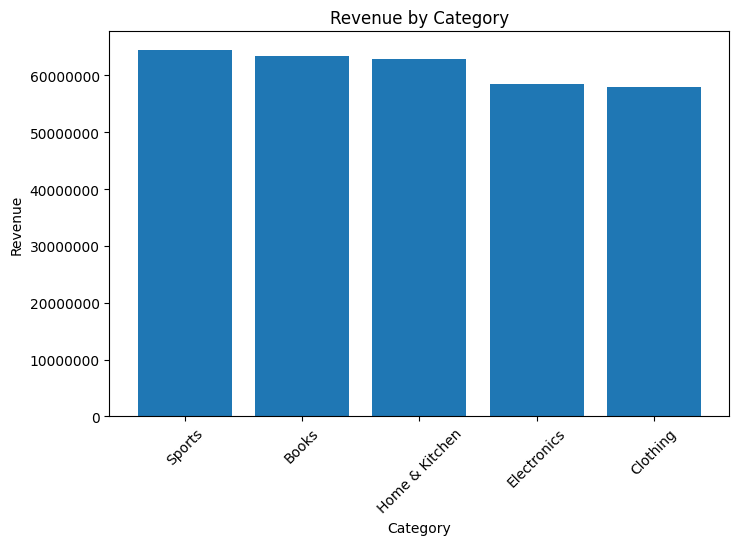

In [41]:
plt.figure(figsize=(8,5))
plt.bar(category_revenue.index, category_revenue.values)
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
# 1e7 hata dega
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.show()

### 2. Pie Chart — Revenue Share by Category

#### What percentage of total revenue comes from each category?

In [42]:
category_revenue = df.groupby('category')['total_amount'].sum()

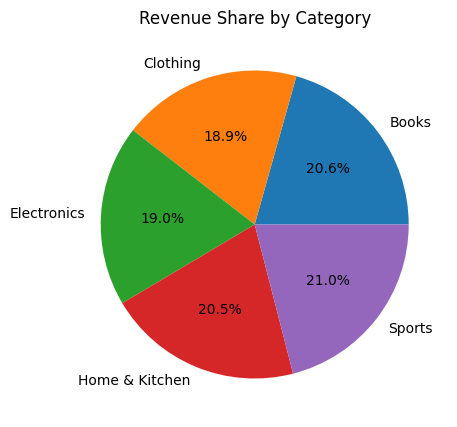

In [43]:
plt.figure(figsize=(5,5))
plt.pie(category_revenue,
        labels=category_revenue.index,
        autopct='%1.1f%%')

plt.title('Revenue Share by Category')
plt.show()

### 3. Count Plot — Orders by City

#### Which city places the highest number of orders?

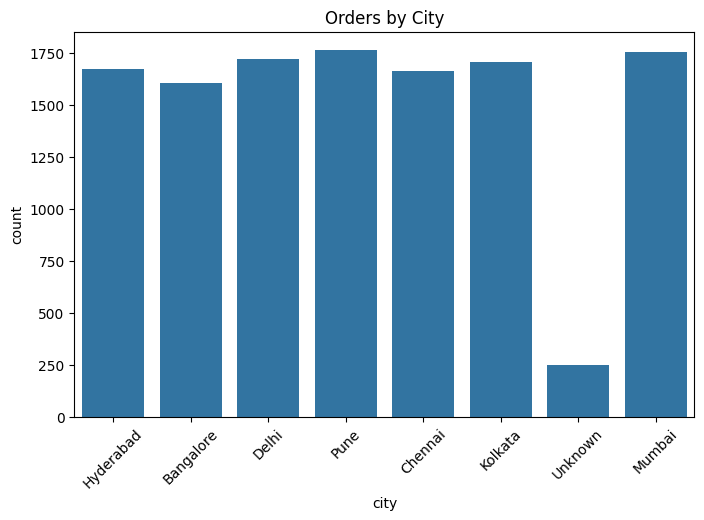

In [44]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='city')

plt.title('Orders by City')
plt.xticks(rotation=45)
plt.show()

### 4. Box Plot — Price Distribution by Category

#### Are there any outliers in product prices across categories?

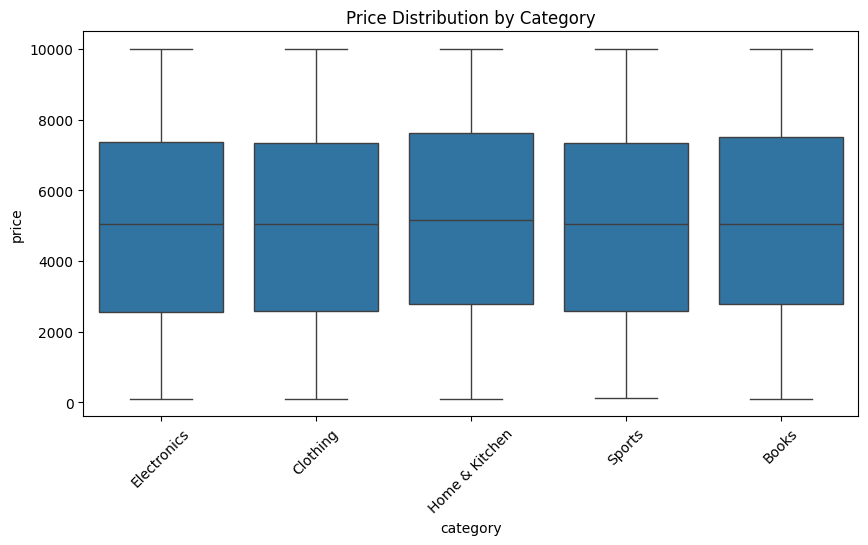

In [45]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,
            x='category',
            y='price')

plt.xticks(rotation=45)
plt.title('Price Distribution by Category')
plt.show()

### 5. Scatter Plot — Price vs total_amount

#### Is there any relationship between product price and total_amount?

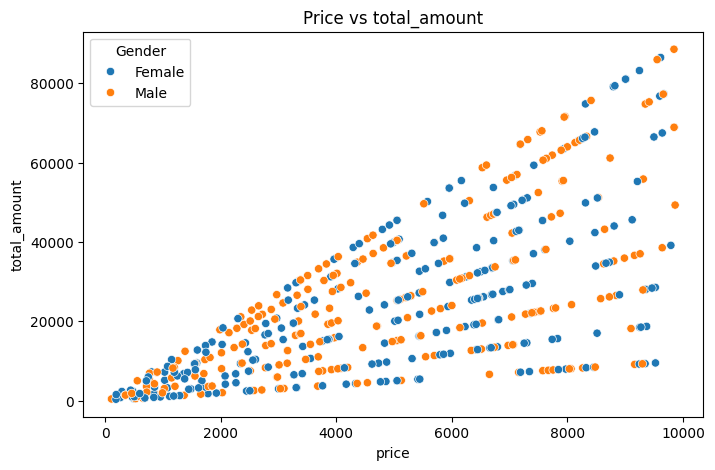

In [46]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df.head(500), x="price", 
                y="total_amount", hue="Gender")

plt.title('Price vs total_amount')
plt.show()

### 6. Line Plot — Monthly Sales Trend

#### How does revenue change over time?

In [47]:
monthly_sales = df.groupby(df['order_date'].dt.to_period('M')) ['total_amount'].sum()

In [48]:
monthly_sales.index = monthly_sales.index.astype(str)

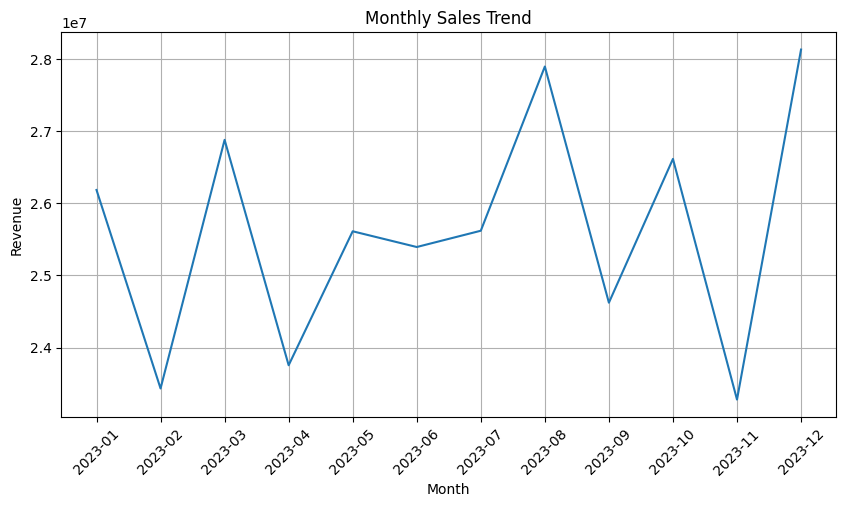

In [49]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index,
         monthly_sales.values)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid()
plt.show()

### 7. Bar Plot — Average Delivery Days by City

#### Which city has the fastest and slowest deliveries?

In [50]:
city_delivery = df.groupby('city')['delivery_days'].mean().sort_values()

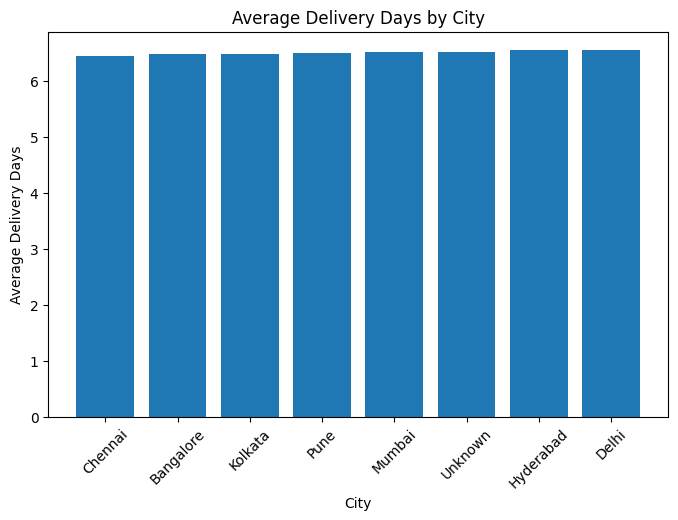

In [51]:
plt.figure(figsize=(8,5))
plt.bar(city_delivery.index,
        city_delivery.values)

plt.title('Average Delivery Days by City')
plt.xlabel('City')
plt.ylabel('Average Delivery Days')
plt.xticks(rotation=45)
plt.show()

## 8. Who are the Top 5 Customers who spent the most money?

In [52]:
top_5_customers = df.groupby("customer_name")["total_amount"].sum().sort_values(ascending=False).head(5)

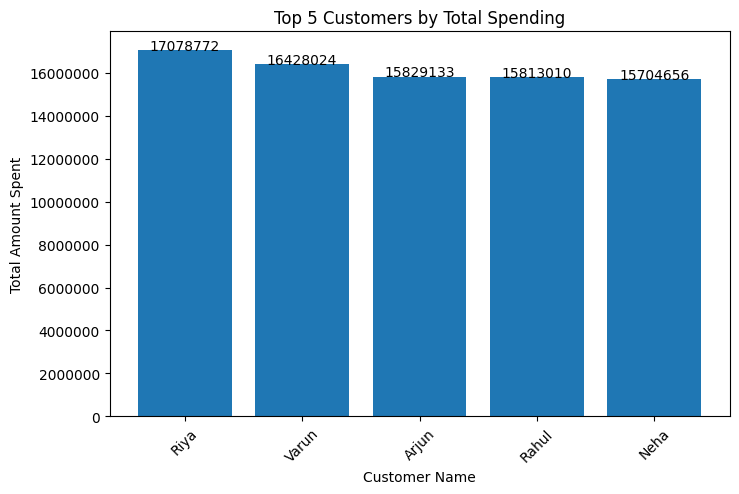

In [53]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    top_5_customers.index,
    top_5_customers.values
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{int(bar.get_height())}',
        ha='center'
    )

plt.title('Top 5 Customers by Total Spending')
plt.xlabel('Customer Name')
plt.ylabel('Total Amount Spent')
plt.xticks(rotation=45)
# 1e7 hata dega
plt.ticklabel_format(style='plain', axis='y')
plt.savefig("top_5.png",dpi=300,bbox_inches="tight")
plt.show()